# Hitting Times

A **hitting time** answers one question: *how long until this random process
first reaches some level?*

- How long until a stock first touches \$120?
- How long until a gambler is up \$50?
- How long until an insurer's reserves first hit \$0? (*ruin*)

`hitting_time(process, level=...)` gives you the answer as a random variable,
which you can then simulate, plot, and summarize like anything else.

In [1]:
from symbulate import *
import matplotlib.pyplot as plt

## Simulate some paths and pick a level

Below are five paths of a Brownian motion -- a random wander that starts at 0.
The dashed line is the level 1. For each path, the hitting time is the first
moment it touches that line. Some paths get there quickly, some late, and some
never get there at all.

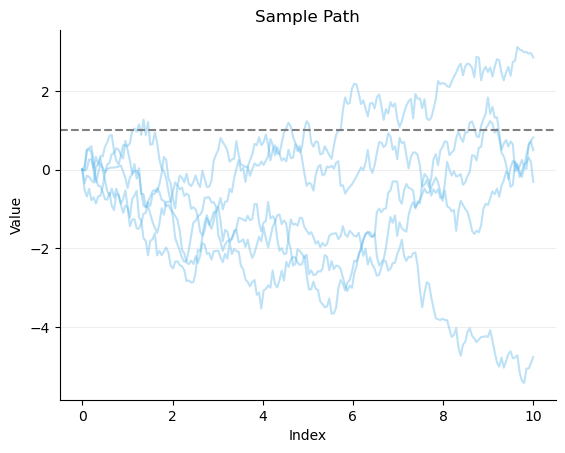

In [2]:
B = BrownianMotion()

B.sim(5).plot(tmin=0, tmax=10)
plt.axhline(1, color="gray", linestyle="--");

## Ask for the hitting time

`max_time` is how long to keep looking before giving up. You need it because
the level might never be reached, and in that case the honest answer is `inf`
(infinity).

The result is a random variable, so simulate it. Each value is how long that
one path took to reach 1.

In [3]:
T = hitting_time(B, level=1, max_time=20)

times = T.sim(1000)
times

0,7.169470596313481
1,6.212499618530277
2,0.6873897552490235
3,2.085522079467773
4,1.1648677825927733
5,5.120702743530275
6,0.6114734649658204
7,0.3031246185302735
8,1.2499996185302735
...,...
999,7.351928329467777


Look closely and some of those values are `inf`: those paths never got to 1
within the 20 units of time we allowed. That is not a failure, it is a real
feature of hitting times -- some paths simply wander the wrong way the whole
time.

So the first thing to report is how many paths arrived at all.

In [4]:
print(f"reached level 1 within 20:  {times.count_leq(20)} of 1000 paths")

reached level 1 within 20:  835 of 1000 paths


## The shape of the distribution

To plot only the paths that arrived, drop the infinities first with
`filter_leq`. Most paths reach the level early, but the tail is very long -- a
few take almost the whole window.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


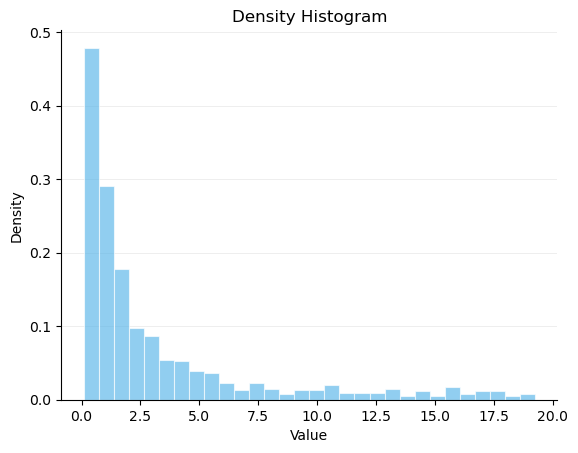

In [5]:
times.filter_leq(20).plot()

That tail is so long that the **average is infinite** -- not merely large,
actually infinite. Symbulate reports that honestly:

In [6]:
times.mean()

inf

So quote the **median** of the paths that arrived instead. Half of them got
there faster than this, half slower.

In [7]:
times.filter_leq(20).median()

1.3999996185302734

## Checking it against a known answer

Brownian motion is one of the few processes where the answer is known on paper.
The chance of reaching level `a` by time `t` is exactly `2 * Phi(-a / sqrt(t))`,
where `Phi` is the normal CDF -- the `.cdf` of a standard `Normal`. Simulation
and formula agree:

In [8]:
Z = Normal(mean=0, sd=1)

for max_time in [1, 4, 16]:
    reached = hitting_time(B, level=1, max_time=max_time).sim(2000).count_leq(max_time)
    exact = 2 * Z.cdf(-1 / max_time**0.5)
    print(f"by time {max_time:>2}:  simulated {reached / 2000:.3f}   exact {exact:.3f}")

by time  1:  simulated 0.320   exact 0.317


by time  4:  simulated 0.612   exact 0.617


by time 16:  simulated 0.807   exact 0.803


## Compare with a process that drifts upward

The answer belongs to the process, not just to the level. `BrownianMotion` with
no drift has no reason to prefer up over down, which is why so many paths never
arrive. Give it a steady upward push and almost all of them do.

In [9]:
drifting = hitting_time(BrownianMotion(drift=1), level=1, max_time=20).sim(1000)

print(f"no drift, reached 1 within 20:  {times.count_leq(20)} of 1000")
print(f"drift 1,  reached 1 within 20:  {drifting.count_leq(20)} of 1000")

no drift, reached 1 within 20:  835 of 1000
drift 1,  reached 1 within 20:  1000 of 1000


## Falling to a level works too

You never say which direction. If the path starts *below* the level,
`hitting_time` looks for the first time it rises to it; if it starts *above*,
the first time it falls to it. Brownian motion starts at 0, so level -1 means
falling. By symmetry, reaching -1 should be just as likely as reaching +1.

In [10]:
up = hitting_time(B, level=1, max_time=4).sim(2000)
down = hitting_time(B, level=-1, max_time=4).sim(2000)

print(f"reached +1 within 4:  {up.count_leq(4)} of 2000")
print(f"reached -1 within 4:  {down.count_leq(4)} of 2000")

reached +1 within 4:  1231 of 2000
reached -1 within 4:  1256 of 2000


## A more realistic question

Put it together with a stock price. A share is worth \$100 today and you want
to sell at \$120. How long might that take?

In [11]:
stock = GeometricBrownianMotion(initial_value=100, growth_rate=0.05, scale=0.3)
wait = hitting_time(stock, level=120, max_time=10).sim(1000)

print(f"hit $120 within 10 years:  {wait.count_leq(10)} of 1000")
print(f"median wait, if it did:    {wait.filter_leq(10).median():.2f} years")

hit $120 within 10 years:  842 of 1000
median wait, if it did:    0.56 years


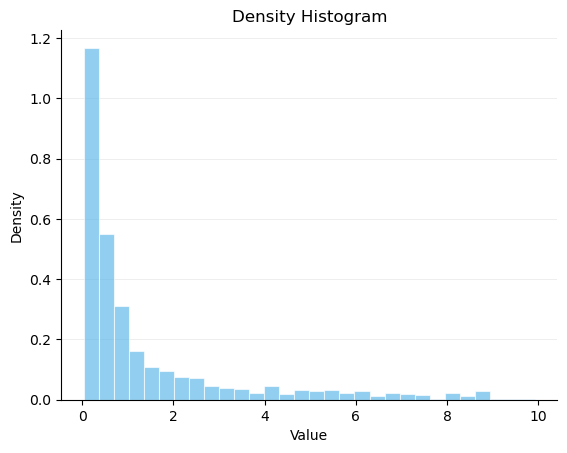

In [12]:
wait.filter_leq(10).plot()

## Why this needs more than a simple scan

Here is the catch, and it is the whole reason this needs a real algorithm
rather than a loop.

A sample path is only ever worked out at the times you ask about. In between
two of those times it is **not** a straight line -- it wiggles. So the path can
pop above the level and come back down without either of the times you looked
at noticing.

Take one path and look at it more and more finely, each time reporting the
highest value seen:

In [13]:
path = BrownianMotion().draw()

for step in [2, 0.5, 0.01]:
    checked = [step * i for i in range(int(10 / step) + 1)]
    print(f"checking every {step:>4}:  highest value seen is {max(path(t) for t in checked):.2f}")

checking every    2:  highest value seen is 0.04
checking every  0.5:  highest value seen is 0.71


checking every 0.01:  highest value seen is 1.09


The number never goes down as you look more finely, and it usually goes up.
Every increase is somewhere the path went that the coarser check walked
straight past -- so any level in between was reached without being noticed.
Looking more finely always finds more, and you can never be sure you have
looked finely enough. A plain scan would report hitting times that are **too
late**, or miss crossings completely.

`hitting_time` avoids the problem instead of out-running it. For a Brownian
motion there is a formula for the *probability* that the path crossed a level
between two values you do know. So rather than looking harder, it flips a coin
weighted by that probability, and nothing can hide. When the coin says a
crossing happened, it cuts the stretch in half over and over to work out when.
The formula and the details are in `symbulate/hitting_times.py`.

## Three things to know

**1. `step` controls precision, not just speed** -- for a *Gaussian* process.
`step` is how far ahead the search looks at a time. Whether the level was
reached, and which `step`-sized stretch it happened in, is exact for Brownian
motion. But pinning down *where inside* that stretch is approximate and leans
slightly late, so the reported time is good to about one `step`. The default
(the search window split into 100) is fine for plotting a distribution; use a
smaller `step` if you need sharp individual times. For the jump and
discrete-time processes below, `step` does nothing at all -- they are exact.

**2. `start_time` looks for a later crossing.** A hitting time is the *first*
time the level is reached. Pass `start_time` to begin the search later on --
just past an earlier crossing, say -- and you get the next one instead.

**3. Three kinds of process are handled, and the accuracy differs.** Gaussian
processes (above) need the crossing formula. Processes that move in jumps, and
discrete-time processes, do not -- and are exact. The rest of this notebook is
about those two.

## Processes that move in jumps

A Poisson process, a queue length, a continuous-time Markov chain, a compound
Poisson total: all of these **hold one value at a time** and change only at
their jumps. That makes hitting times easy *and* exact -- a path that is flat
between jumps cannot sneak past a level and back, so walking the jumps sees
everything. Nothing wiggles, nothing is missed, and no `step` is needed.

Start with a Poisson process. Its count reaches 4 at the moment of the 4th
arrival, so its hitting time *is* the 4th arrival time -- which we can check
exactly, on a single path.

In [14]:
N = PoissonProcess(rate=2)
path = N.draw()

print(f"4th arrival time:        {float(path.get_arrival_times()[3]):.6f}")
print(f"time the count hits 4:   {hitting_time(path, level=4, max_time=100):.6f}")

4th arrival time:        2.796362
time the count hits 4:   2.796362


Identical, not merely close. And because the 4th arrival of a rate-2 Poisson
process has a `Gamma(4, 2)` distribution, the mean hitting time is exactly
`4 / 2 = 2` -- another answer known on paper to check against.

In [15]:
arrivals = hitting_time(N, level=4, max_time=1000).sim(10000)
print(f"simulated mean:  {arrivals.mean():.3f}")
print(f"exact (k / rate): {4 / 2:.3f}")

simulated mean:  1.971
exact (k / rate): 2.000


### How long until the queue has five people in it?

The same call works on a queue, where the path is the number of customers in
the system. This is the question the utility exists for: it is not a formula
anyone wants to derive for a general-service queue.

In [16]:
queue = GG1(Exponential(rate=1), Exponential(rate=1.2))
busy = hitting_time(queue, level=5, max_time=200).sim(1000)

print(f"reached 5 in line within 200:  {busy.count_leq(200)} of 1000")
print(f"median wait until it did:      {busy.filter_leq(200).median():.1f}")

reached 5 in line within 200:  1000 of 1000
median wait until it did:      14.6


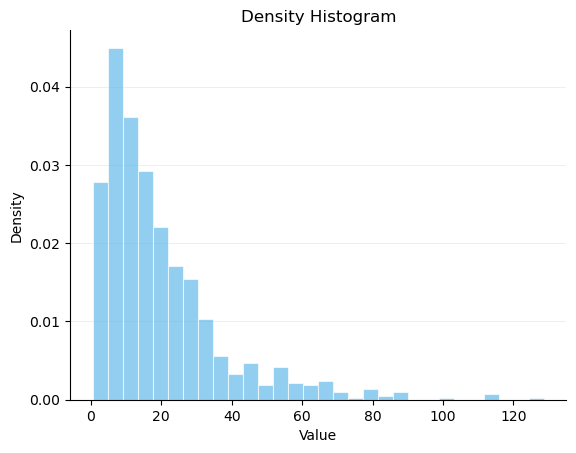

In [17]:
busy.filter_leq(200).plot()

### Ruin

An insurer's surplus goes up with premiums and down with claims. Model the net
change as a compound Poisson process with negative jumps, and *ruin* is the
first time the surplus falls to a level -- which is a hitting time, not a
separate thing to build.

In [18]:
surplus = CompoundPoissonProcess(rate=1, jump_dist=Normal(mean=-1, sd=3))
ruin = hitting_time(surplus, level=-20, max_time=100).sim(1000)

print(f"ruined (fell to -20) within 100:  {ruin.count_leq(100)} of 1000")
print(f"median time to ruin, if ruined:   {ruin.filter_leq(100).median():.1f}")

ruined (fell to -20) within 100:  998 of 1000
median time to ruin, if ruined:   18.4


## Discrete-time processes

A random walk, a Markov chain, and a moving-average series have a value at each
step and nothing in between, so again there is nothing to miss. The answer here
is a **step number**, because for these processes a step *is* the unit of time
-- and so is `max_time`.

The classic check: a `+-1` walk that steps up with probability `p > 1/2` reaches
level 1 after `1 / (2p - 1)` steps on average.

In [19]:
walk = RandomWalk(p=0.7)
steps = hitting_time(walk, level=1, max_time=2000).sim(5000)

print(f"simulated mean steps:  {steps.mean():.3f}")
print(f"exact 1 / (2p - 1):    {1 / (2 * 0.7 - 1):.3f}")

simulated mean steps:  2.449
exact 1 / (2p - 1):    2.500


And the other classic: a walk drifting *downward* reaches level 1 only
sometimes -- with probability `p / (1 - p)`, and never otherwise. The paths that
never make it report `inf`, which is the honest answer rather than a very large
number.

In [20]:
sinking = hitting_time(RandomWalk(p=0.3), level=1, max_time=1000).sim(2000)

print(f"ever reached 1:   {sinking.count_leq(1000) / 2000:.3f}")
print(f"exact p / (1 - p): {0.3 / 0.7:.3f}")

ever reached 1:   0.435
exact p / (1 - p): 0.429


### One difference worth knowing: reaching means reaching *or passing*

A walk that goes from 4 to 6 is never at 5. So for a jump or discrete-time
process, "reaching a level" has to mean getting to it **or past it** -- and
asking about 4.5 gives the same answer as asking about 5.

(For a Gaussian process this cannot come up: a continuous path has no way to get
to the other side of a level without touching it.)

In [21]:
climbing = RandomWalk(p=1).draw()  # steps up by 1 every time: 0, 1, 2, 3, ...

for level in [4, 4.5, 5]:
    print(f"level {level}: reached at step {hitting_time(climbing, level=level, max_time=50)}")

level 4: reached at step 4.0
level 4.5: reached at step 5.0
level 5: reached at step 5.0


### When does the weather first turn?

A Markov chain works the same way, with one catch: a level needs an *order*, so
label the states with numbers rather than names. Starting in state 0 of the
chain below, the first step spent in state 1 is geometric with success
probability 0.25, so it takes 4 steps on average.

In [22]:
chain = MarkovChain([[0.75, 0.25], [0.5, 0.5]], [1.0, 0.0])
first_visit = hitting_time(chain, level=1, max_time=500).sim(5000)

print(f"simulated mean steps:  {first_visit.mean():.3f}")
print(f"exact 1 / 0.25:        {1 / 0.25:.3f}")

simulated mean steps:  4.060
exact 1 / 0.25:        4.000


Label the same chain with names and it says so, rather than guessing at an
order:

In [23]:
named = MarkovChain(
    [[0.75, 0.25], [0.5, 0.5]], [1.0, 0.0], state_labels=["sun", "rain"]
)

try:
    hitting_time(named.draw(), level=1)
except TypeError as error:
    print(error)

At step 0, the process is at 'sun', which is not a number, so there is no way to tell whether it has reached a level. Asking when a process reaches a level only makes sense for one whose values are numbers. If this is a Markov chain, label its states with numbers -- MarkovChain(P, initial, state_labels=[0, 1, 2]) -- rather than with names.


## What is not handled yet

A general diffusion -- `DiffusionProcess` or `CIR` -- needs its own
approximation, which is not built. So does a
`NonHomogeneousPoissonProcess` or `CoxProcess` count: it *does* move in jumps,
but it knows when those jumps happen on the "expected number of events" scale
rather than on the clock, and working back to a time from that is not built
either. Both say so plainly instead of returning a wrong number.

In [24]:
for process in [CIR(), CoxProcess(intensity=Gamma(shape=2, rate=1))]:
    try:
        hitting_time(process.draw(), level=3, max_time=50)
    except NotImplementedError as error:
        print(type(process).__name__, "->", error, "\n")

CIR -> hitting_time does not know how to read a CIRResult yet. It handles Gaussian processes (BrownianMotion, BrownianBridge, OrnsteinUhlenbeck, FractionalBrownianMotion, GeometricBrownianMotion, or a GaussianProcess you built yourself), processes that move in jumps (PoissonProcess, RenewalProcess, CompoundPoissonProcess, ContinuousTimeMarkovChain, the birth-death and M/M queues, and the G/G queues), and discrete-time processes (RandomWalk, MarkovChain, MA). A DiffusionProcess or CIR needs its own approximation, which is not built yet. A process whose value is several numbers at once, such as an epidemic model, has no single level to reach -- ask about one compartment of it instead. 

CoxProcess -> hitting_time cannot read a NonHomogeneousPoissonProcess or CoxProcess path yet. Its count does move in jumps, but unlike a PoissonProcess it does not know when those jumps happen on the clock -- it knows them on the 'expected number of events' scale, and working back to a time from that is n